In [222]:
import pandas as pd

# مسار الملف المحفوظ Local path
data_path = "car_fuel_efficiency_2026.csv"

# قراءة الملف Load CSV into DataFrame
df = pd.read_csv(data_path)

# عرض أول 5 أسطر لمعاينة البيانات Display first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

# عرض معلومات عن الأعمدة وأنواع البيانات Data summary
print("\nDataset Info:")
print(df.info())

First 5 rows of the dataset:
   model_year  origin fuel type         drivetrain  num_doors  \
0        2006  Europe  Gasoline  Front-wheel drive          4   
1        2008  Europe    Diesel  Front-wheel drive          4   
2        1996    Asia  Gasoline  Front-wheel drive          5   
3        1989  Europe  Gasoline  Front-wheel drive          4   
4        1994     USA    Diesel  Front-wheel drive          3   

   engine_displacement  num_cylinders  horsepower  vehicle_weight  \
0                 2180              6       243.0            3870   
1                 2390              6       272.0            4210   
2                 2320              6       267.0            4240   
3                 2130              6       258.0            4490   
4                 2580              7       304.0            4510   

   acceleration  fuel_efficiency_mpg  
0           NaN                 31.9  
1           NaN                 31.3  
2          17.3                 27.5  
3        

In [223]:
df.columns=df.columns.str.replace(' ','_')
list(df.dtypes[df.dtypes == 'object'].index)

['origin', 'fuel_type', 'drivetrain']

In [224]:
df.dtypes

model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [225]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print(df[col].nunique())
    print()


model_year
[2006 2008 1996 1989 1994 2007 1992 2005 1997 2004 1978 1983 2024 2015
 2021 1995 2020 2016 2019 2012 1990 1993 2017 1976 1977 2002 2023 1975
 1982 1979 2003 2014 1985 1984 1986 1999 2018 1998 1988 2001 1981 2000
 2013 2010 2011 1987 2009 1991 2022 1980]
50

origin
['Europe' 'Asia' 'USA']
3

fuel_type
['Gasoline' 'Diesel' 'Hybrid']
3

drivetrain
['Front-wheel drive' 'Rear-wheel drive' 'All-wheel drive']
3

num_doors
[4 5 3 2]
4

engine_displacement
[2180 2390 2320 2130 2580 2290 2270 2370 2330 2410 2240 2440 1900 2170
 2280 2540 2490 2300 2350 2610 2160 2260 2010 2460 2080 2070 2620 2560
 2420 2200 2530 2360 2340 2150 2500 2400 2740 2140 2190 1980 1960 2100
 1890 2310 1910 2110 2450 2650 2220 2020 2550 2430 2470 2250 2090 2380
 2230 1820 2510 2210 1920 2120 2040 1930 1880 2480 1780 1670 1950 1940
 2640 2060 2000 2570 2710 2680 1790 2600 1970 2700 1810 2030 2630 2520
 1870 2670 2050 1990 2690 2590 1850 1750 1860 1840 2790 1700 2720 2660
 1800 2960 2750 1760 2830 2820 2760 278

In [226]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [227]:
print(sorted(df.fuel_efficiency_mpg.unique()))

[np.float64(19.8), np.float64(20.2), np.float64(20.5), np.float64(20.7), np.float64(20.9), np.float64(21.2), np.float64(21.3), np.float64(21.4), np.float64(21.5), np.float64(21.6), np.float64(21.7), np.float64(21.8), np.float64(21.9), np.float64(22.0), np.float64(22.1), np.float64(22.2), np.float64(22.3), np.float64(22.4), np.float64(22.5), np.float64(22.6), np.float64(22.7), np.float64(22.8), np.float64(22.9), np.float64(23.0), np.float64(23.1), np.float64(23.2), np.float64(23.3), np.float64(23.4), np.float64(23.5), np.float64(23.6), np.float64(23.7), np.float64(23.8), np.float64(23.9), np.float64(24.0), np.float64(24.1), np.float64(24.2), np.float64(24.3), np.float64(24.4), np.float64(24.5), np.float64(24.6), np.float64(24.7), np.float64(24.8), np.float64(24.9), np.float64(25.0), np.float64(25.1), np.float64(25.2), np.float64(25.3), np.float64(25.4), np.float64(25.5), np.float64(25.6), np.float64(25.7), np.float64(25.8), np.float64(25.9), np.float64(26.0), np.float64(26.1), np.float6

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

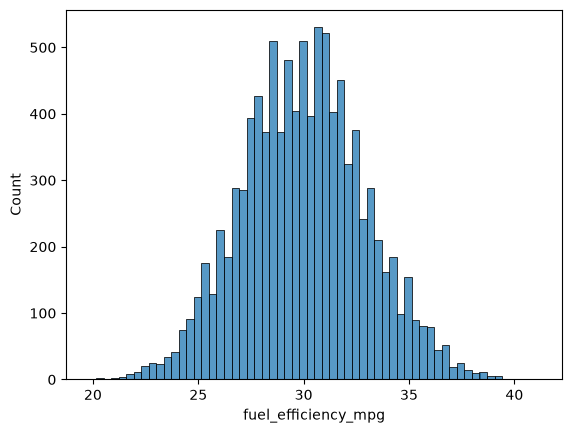

In [228]:
sns.histplot(df.fuel_efficiency_mpg)

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

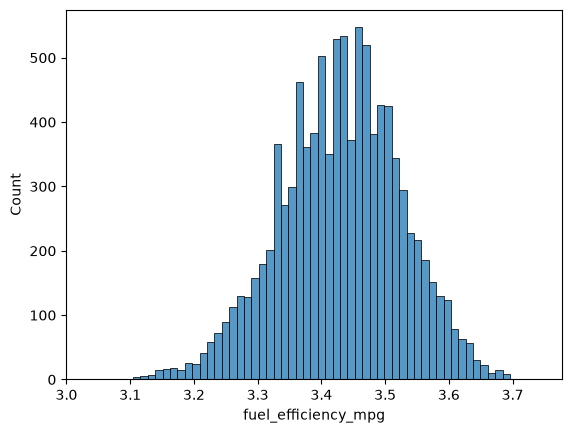

In [229]:
import numpy as np
np.log1p([0,10,1000,1000000])
fuel_logs=np.log1p(df.fuel_efficiency_mpg)
sns.histplot(fuel_logs)

In [230]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

In [231]:
n=len(df)
n_val=int(n*0.2)
n_test=int(n*0.2)
n_train=n-n_test-n_val
n,n_val+n_test+n_train

(10000, 10000)

In [232]:
df_train=df.iloc[:n_train]
df_val=df.iloc[n_train:n_val+n_train]
df_test=df.iloc[n_val+n_train:]


In [233]:

idx=np.arange(n)
np.random.seed(2)
np.random.shuffle(idx)
idx
df_train=df.iloc[idx[:n_train]]
df_val=df.iloc[idx[n_train:n_val+n_train]]
df_test=df.iloc[idx[n_val+n_train:]]


In [234]:
df_train.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
7878,2013,USA,Diesel,All-wheel drive,2,2520,7,297.0,4510,17.8,32.0
3224,2012,Europe,Gasoline,Front-wheel drive,2,1970,6,237.0,3990,17.9,31.9
1919,2008,Asia,Gasoline,Rear-wheel drive,4,2250,6,245.0,4230,18.2,28.7
4432,2021,USA,Gasoline,All-wheel drive,4,2120,6,227.0,4420,20.5,29.9
4835,2003,Europe,Diesel,Front-wheel drive,5,2260,6,264.0,4090,16.9,31.8


In [235]:
len(df_train),len(df_test),len(df_val)

(6000, 2000, 2000)

In [236]:
df_train=df_train.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)

In [237]:
df_train.engine_displacement=np.log1p(df_train.engine_displacement.values)
df_test.engine_displacement=np.log1p(df_test.engine_displacement.values)
df_val.engine_displacement=np.log1p(df_val.engine_displacement.values)
df_train

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2013,USA,Diesel,All-wheel drive,2,7.832411,7,297.0,4510,17.8,32.0
1,2012,Europe,Gasoline,Front-wheel drive,2,7.586296,6,237.0,3990,17.9,31.9
2,2008,Asia,Gasoline,Rear-wheel drive,4,7.719130,6,245.0,4230,18.2,28.7
3,2021,USA,Gasoline,All-wheel drive,4,7.659643,6,227.0,4420,20.5,29.9
4,2003,Europe,Diesel,Front-wheel drive,5,7.723562,6,264.0,4090,16.9,31.8
...,...,...,...,...,...,...,...,...,...,...,...
5995,2006,Asia,Diesel,Front-wheel drive,4,7.719130,6,250.0,4040,20.2,35.5
5996,2006,Asia,Gasoline,Front-wheel drive,3,7.775276,6,246.0,4280,18.5,28.8
5997,1998,USA,Gasoline,Front-wheel drive,3,7.692113,5,240.0,4190,19.0,29.3
5998,1987,USA,Hybrid,Front-wheel drive,3,7.816417,6,275.0,4370,20.4,29.2


In [238]:
y_train=df_train['fuel_efficiency_mpg']
y_val=df_val.fuel_efficiency_mpg
y_test=df_test.fuel_efficiency_mpg



In [239]:
del df_val['fuel_efficiency_mpg']
del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
df_train[:5]

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration
0,2013,USA,Diesel,All-wheel drive,2,7.832411,7,297.0,4510,17.8
1,2012,Europe,Gasoline,Front-wheel drive,2,7.586296,6,237.0,3990,17.9
2,2008,Asia,Gasoline,Rear-wheel drive,4,7.719130,6,245.0,4230,18.2
3,2021,USA,Gasoline,All-wheel drive,4,7.659643,6,227.0,4420,20.5
4,2003,Europe,Diesel,Front-wheel drive,5,7.723562,6,264.0,4090,16.9


In [240]:
df_train.iloc[10]

model_year                          1987
origin                               USA
fuel_type                       Gasoline
drivetrain             Front-wheel drive
num_doors                              2
engine_displacement             7.596392
num_cylinders                          6
horsepower                         238.0
vehicle_weight                      4070
acceleration                        17.9
Name: 10, dtype: object

In [241]:
xi=[2,7.596392,6,238.0,4070,17.9]

In [242]:
w0=2
w=[0.1,0.001,0.004,0.023,0.04,0.00001]

In [243]:
def dot(xi,w):
    n=len(xi)
    res=0.0
    for j in range(n):
        res=res+xi[j]*w[j]
    return res

In [244]:
w_new=[w0]+w
w_new

[2, 0.1, 0.001, 0.004, 0.023, 0.04, 1e-05]

In [245]:
def linear_regression(xi):
    xi=[1]+xi
    return dot(xi,w_new)

In [246]:
linear_regression(xi)

170.505775392

In [247]:
xi=[453,11,86]
w0=7.17
w=[0.01,0.04,0.002]
w_new=[w0] + w

In [248]:
x1  = [1,148,24,1385]
x2  = [1,132,25,2031]
x10 = [1,453,11,86]

X=[x1,x2,x10]
X=np.array(X)

In [249]:
def linear_regression(X):
    return X.dot(w_new)

In [250]:
linear_regression(X)

array([12.38 , 13.552, 12.312])

In [251]:
def train_linear_regression(X,y):
    pass

In [252]:
X=[
 [148,24,1385],
 [132,25,2031],
 [453,166,86],
 [148,52,1890],
  [132,35,2341],
  [453,51,36],
  [1423,24,8685],
   [152,25,9091],
   [4325,15,12],

]
y = [100,200,56,45,265,99,250,650,300]
X=np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,  166,   86],
       [ 148,   52, 1890],
       [ 132,   35, 2341],
       [ 453,   51,   36],
       [1423,   24, 8685],
       [ 152,   25, 9091],
       [4325,   15,   12]])

In [253]:
ones= np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [254]:
XTX=X.T.dot(X)
XTX_inv=np.linalg.inv(XTX)
XTX_inv,'+++++++++',XTX

(array([[ 5.20466590e-08, -2.44626061e-07, -3.46912293e-09],
        [-2.44626061e-07,  3.07787113e-05, -1.06233949e-07],
        [-3.46912293e-09, -1.06233949e-07,  6.51237073e-09]]),
 '+++++++++',
 array([[ 21242732,    220296,  14909557],
        [   220296,     36713,    716237],
        [ 14909557,    716237, 173179909]]))

In [255]:
w_full=XTX_inv.dot(X.T).dot(y)

w0 = w_full[0]
w = w_full[1:]


In [256]:
w0,w

(np.float64(0.052039614160137415), array([0.39157986, 0.04784702]))

In [257]:
def train_linear_regression(X,y):
    ones=np.ones(X.shape[0])
    X=np.column_stack([ones,X])

    XTX=X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full= XTX_inv.dot(X.T).dot(y)

    return w_full[0],w_full[1:]

In [258]:
train_linear_regression(X,y)

(np.float64(118.9816238465766), array([ 0.02911111, -0.59808382,  0.03635536]))

In [259]:
d=np.array([[1,2,3],
           [4,5,6],
           [7,8,9]])
dTd=d.T @ d
dTd_inv=np.linalg.inv(dTd)

In [260]:
df_train.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration
0,2013,USA,Diesel,All-wheel drive,2,7.832411,7,297.0,4510,17.8
1,2012,Europe,Gasoline,Front-wheel drive,2,7.586296,6,237.0,3990,17.9
2,2008,Asia,Gasoline,Rear-wheel drive,4,7.719130,6,245.0,4230,18.2
3,2021,USA,Gasoline,All-wheel drive,4,7.659643,6,227.0,4420,20.5
4,2003,Europe,Diesel,Front-wheel drive,5,7.723562,6,264.0,4090,16.9


In [274]:
df_train.dtypes ,['num_doors','num_cylinders','horsepower','vehicle_weight','acceleration']

(model_year               int64
 origin                  object
 fuel_type               object
 drivetrain              object
 num_doors                int64
 engine_displacement    float64
 num_cylinders            int64
 horsepower             float64
 vehicle_weight           int64
 acceleration           float64
 dtype: object,
 ['num_doors',
  'num_cylinders',
  'horsepower',
  'vehicle_weight',
  'acceleration'])

In [ ]:
base=['num_doors','num_cylinders','horsepower','vehicle_weight','acceleration']
df_train[base]

,num_doors,num_cylinders,horsepower,vehicle_weight,acceleration
0,2,7,297.0,4510,17.8
1,2,6,237.0,3990,17.9
2,4,6,245.0,4230,18.2
3,4,6,227.0,4420,20.5
4,5,6,264.0,4090,16.9
...,...,...,...,...,...
5995,4,6,250.0,4040,20.2
5996,3,6,246.0,4280,18.5
5997,3,5,240.0,4190,19.0
5998,3,6,275.0,4370,20.4


In [ ]:
x_train=df_train[base].values
x_train

array([[2.00e+00, 7.00e+00, 2.97e+02, 4.51e+03, 1.78e+01],
       [2.00e+00, 6.00e+00, 2.37e+02, 3.99e+03, 1.79e+01],
       [4.00e+00, 6.00e+00, 2.45e+02, 4.23e+03, 1.82e+01],
       ...,
       [3.00e+00, 5.00e+00, 2.40e+02, 4.19e+03, 1.90e+01],
       [3.00e+00, 6.00e+00, 2.75e+02, 4.37e+03, 2.04e+01],
       [4.00e+00, 6.00e+00, 2.83e+02, 4.59e+03, 1.81e+01]],
      shape=(6000, 5))

In [264]:
x_train=df_train[base].fillna(0).values


In [265]:
w0,w=train_linear_regression(x_train,y_train)

In [268]:
y_pred= w0 + x_train.dot(w)
y_pred

array([28.7764086 , 31.21704083, 30.46081659, ..., 30.69925234,
       29.71896614, 28.94408996], shape=(6000,))

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

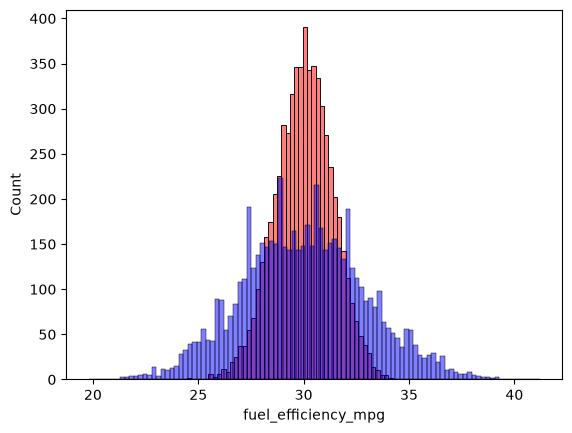

In [273]:
sns.histplot(y_pred,color='red',alpha=0.5,bins=50)
sns.histplot(y_train,color='blue',alpha=0.5,bins=100)

In [276]:
Mt=sum((y_pred-y_train)**2)/len(y_train)
M=np.sqrt(Mt)
M

np.float64(2.618294637617042)

In [277]:
def rmse(y,y_pred):
    errors=y_pred-y
    se=errors**2
    mse=se.mean()
    return np.sqrt(mse)

In [278]:
rmse(y_train,y_pred)

np.float64(2.618294637617042)

In [279]:
base=['num_doors','num_cylinders','horsepower','vehicle_weight','acceleration']
x_train=df_train[base].fillna(0).values

w0,w=train_linear_regression(x_train,y_train)

y_pred= w0 + x_train.dot(w)
